# Budowa modelu klasyfikacji sentymentu

Notebook odtwarza etap modelowania opisany w raporcie. Dane wejściowe pochodzą z pliku `data/trump_tweets_preprocessed.csv`, a wynikiem jest model klasyfikujący tweety do klas `negative`, `neutral` i `positive` oraz wykres macierzy pomyłek zapisany w katalogu `figures/`.

## Instalacja bibliotek

W Google Colab można odkomentować poniższą komórkę, jeżeli biblioteki nie są jeszcze zainstalowane.

In [19]:
# !pip install pandas numpy matplotlib scikit-learn

## Import bibliotek

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

## Konfiguracja ścieżek i parametrów

Kod działa zarówno po uruchomieniu notebooka z katalogu głównego repozytorium, jak i bezpośrednio z katalogu `notebooks/`.

In [21]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "trump_tweets_preprocessed.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_FEATURES = 5000

DATA_PATH, FIGURES_DIR

(PosixPath('/Users/abalski/Downloads/code-incubator/sentiment-shap-trump-tweets/data/trump_tweets_preprocessed.csv'),
 PosixPath('/Users/abalski/Downloads/code-incubator/sentiment-shap-trump-tweets/figures'))

## Wczytanie danych

In [22]:
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["clean_text", "sentiment"]).copy()

print(f"Liczba rekordów: {len(df):,}".replace(",", " "))
display(df[["clean_text", "sentiment", "vader_score"]].head())

Liczba rekordów: 42 998


,clean_text,sentiment,vader_score
0,be sure to tune in and watch donald trump on l...,positive,0.5255
1,donald trump will be appearing on the view tom...,positive,0.7712
2,donald trump reads top ten financial tips on l...,positive,0.6468
3,new blog post celebrity apprentice finale and ...,neutral,0.0000
4,my persona will never be that of a wallflower ...,neutral,0.0000


In [23]:
class_counts = df["sentiment"].value_counts()
class_share = (df["sentiment"].value_counts(normalize=True) * 100).round(2)

pd.DataFrame({
    "liczba_tweetów": class_counts,
    "udział_%": class_share,
})

,liczba_tweetów,udział_%
sentiment,,
positive,25038,58.23
negative,10660,24.79
neutral,7300,16.98


## Podział na zbiór treningowy i testowy

Podział jest stratyfikowany, aby zachować podobny rozkład klas w części treningowej i testowej.

In [24]:
X = df["clean_text"].astype(str)
y = df["sentiment"].astype(str)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Zbiór treningowy: {len(X_train_text):,}".replace(",", " "))
print(f"Zbiór testowy: {len(X_test_text):,}".replace(",", " "))

Zbiór treningowy: 34 398
Zbiór testowy: 8 600


## Reprezentacja TF-IDF

Wektoryzator jest dopasowany tylko na zbiorze treningowym. Zbiór testowy jest wyłącznie transformowany, aby uniknąć data leakage.

In [25]:
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    stop_words="english",
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"Liczba cech TF-IDF: {X_train.shape[1]:,}".replace(",", " "))

Liczba cech TF-IDF: 5 000


## Trenowanie modelu

Zastosowano regresję logistyczną z wagami klas, ponieważ zbiór nie jest zbalansowany.

In [26]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

labels = list(model.classes_)
labels

['negative', 'neutral', 'positive']

## Ocena jakości modelu

In [27]:
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Accuracy: 0.8106
Macro F1: 0.7859
Weighted F1: 0.8160


In [28]:
report = classification_report(
    y_test,
    y_pred,
    labels=labels,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
negative,0.730246,0.806285,0.766384,2132.000000
neutral,0.631394,0.862329,0.729010,1460.000000
positive,0.939087,0.797324,0.862419,5008.000000
accuracy,0.810581,0.810581,0.810581,0.810581
macro avg,0.766909,0.821979,0.785938,8600.000000
weighted avg,0.835078,0.810581,0.815963,8600.000000


## Macierz pomyłek

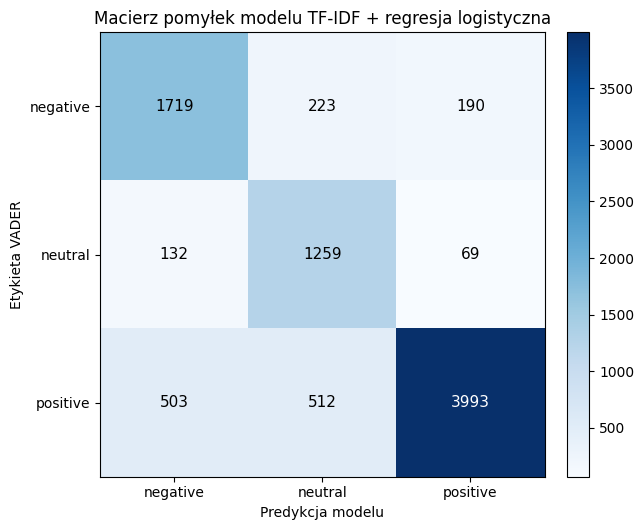

PosixPath('/Users/abalski/Downloads/code-incubator/sentiment-shap-trump-tweets/figures/confusion_matrix.png')

In [29]:
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6.7, 5.4))
image = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)), labels=labels)
ax.set_yticks(np.arange(len(labels)), labels=labels)
ax.set_xlabel("Predykcja modelu")
ax.set_ylabel("Etykieta VADER")
ax.set_title("Macierz pomyłek modelu TF-IDF + regresja logistyczna")

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color=color, fontsize=11)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

output_path = FIGURES_DIR / "confusion_matrix.png"
fig.savefig(output_path, dpi=220)
plt.show()

output_path

## Najważniejsze współczynniki modelu

Poniższa komórka pomaga szybko sprawdzić, które cechy model liniowy najsilniej wiąże z daną klasą.

In [30]:
feature_names = np.array(vectorizer.get_feature_names_out())

top_rows = []
for class_index, class_name in enumerate(labels):
    coefficients = model.coef_[class_index]
    top_positive_indices = np.argsort(coefficients)[-10:][::-1]
    top_negative_indices = np.argsort(coefficients)[:10]

    for rank, feature_index in enumerate(top_positive_indices, start=1):
        top_rows.append({
            "class": class_name,
            "direction": "supports_class",
            "rank": rank,
            "feature": feature_names[feature_index],
            "coefficient": coefficients[feature_index],
        })

    for rank, feature_index in enumerate(top_negative_indices, start=1):
        top_rows.append({
            "class": class_name,
            "direction": "weakens_class",
            "rank": rank,
            "feature": feature_names[feature_index],
            "coefficient": coefficients[feature_index],
        })

top_coefficients = pd.DataFrame(top_rows)
top_coefficients

,class,direction,rank,feature,coefficient
0,negative,supports_class,1,bad,6.031033
1,negative,supports_class,2,worst,4.893267
2,negative,supports_class,3,disaster,4.804272
3,negative,supports_class,4,illegal,4.466887
4,negative,supports_class,5,terrible,4.400633
5,negative,supports_class,6,war,4.357284
6,negative,supports_class,7,failed,4.349140
7,negative,supports_class,8,fired,4.331569
8,negative,supports_class,9,sad,4.096716
9,negative,supports_class,10,killed,3.966970


## Podsumowanie

Ten notebook tworzy model opisany w raporcie i zapisuje wykres `figures/confusion_matrix.png`.